In [11]:
#install dependecies in enviroment
!pip install fastapi uvicorn python-multipart  rembg numpy opencv-contrib-python "rembg[cpu]" pytesseract ipykernel matplotlib paddlepaddle==3.0.0 paddleocr easyocr

  Using cached fastapi-0.136.3-py3-none-any.whl.metadata (27 kB)
  Using cached uvicorn-0.49.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
  Using cached rembg-2.0.76-py3-none-any.whl.metadata (18 kB)
  Using cached starlette-1.3.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached pooch-1.9.0-py3-none-any.whl.metadata (10 kB)
  Using cached pymatting-1.1.15-py3-none-any.whl.metadata (8.7 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
Using cached fastapi-0.136.3-py3-none-any.whl (117 kB)
Using cached uvicorn-0.49.0-py3-none-any.whl (71 kB)
Usin

In [1]:
import cv2
import numpy as np
import os
import sys
import time
from PIL import Image
import pytesseract
from pytesseract import Output
import easyocr
import re
import matplotlib.pyplot as plt
from paddleocr import PaddleOCR
# maybe ill do the bonus part but for now ill import it anyways
from fastapi import FastAPI, File, UploadFile
from fastapi.responses import JSONResponse
from rembg import remove
from PIL import Image
from paddleocr import TextDetection
ocr = PaddleOCR(use_textline_orientation=True, lang='ar')
reader = easyocr.Reader(['ar', 'en'], gpu=False)

/mnt/D/idkkkkk/jobtrailOCR/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
which: no ccache in (/mnt/D/idkkkkk/jobtrailOCR/.venv/bin:/usr/local/bin:/usr/bin:/bin:/usr/local/sbin:/var/lib/flatpak/exports/bin:/usr/bin/site_perl:/usr/bin/vendor_perl:/usr/bin/core_perl:/home/ROKAIA/.spicetify)
/mnt/D/idkkkkk/jobtrailOCR/.venv/lib/python3.11/site-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/home/ROKAIA/.pad

In [2]:
def findBESTCardContour(imagname, filePath):
    # background removal
    # i noticed that it works better on an id with no background
    inputImage = Image.open(filePath)
    noBG = remove(inputImage)
    noBG = np.array(noBG) 
    show_img("no background", noBG)

   # alpha to mask foreground
    alpha = noBG[:,:,3]
    _, fgmask = cv2.threshold(alpha, 0, 255, cv2.THRESH_BINARY)
    show_img("Foreground Mask", fgmask)

    # clean up 
    kerfg = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 15))
    fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_CLOSE, kerfg, iterations=2)
    fgmask = cv2.dilate(fgmask, kerfg, iterations=2)

    fgcontours, _ = cv2.findContours(fgmask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not fgcontours:
        return None

    largestfg = max(fgcontours, key=cv2.contourArea)
    hull = cv2.convexHull(largestfg)
    filledmask = np.zeros_like(fgmask)
    cv2.drawContours(filledmask, [hull], -1, 255, -1)
    show_img("Filled Foreground Mask", filledmask)

# crop to box of foreground region 
    x, y, w, h = cv2.boundingRect(hull)
    pad_x = int(w * 0.15)
    pad_y = int(h * 0.15)
    x0, y0 = max(0, x - pad_x), max(0, y - pad_y)
    x1, y1 = min(imagname.shape[1], x + w + pad_x), min(imagname.shape[0], y + h + pad_y)
    cropped = imagname[y0:y1, x0:x1]
    show_img("Cropped Region", cropped)
    image = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(cropped, cv2.COLOR_BGR2HSV)
    sat = hsv[:,:,2]
    img_area = cropped.shape[0] * cropped.shape[1]
    ker = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
    fgcrop = filledmask[y0:y1, x0:x1]
    candidates = [fgcrop]
    
# Otsu 
    _, Maskotso = cv2.threshold(sat,0,255,cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    candidates.append(Maskotso)
#Otsu inverted 
    _, Maskotsoinv = cv2.threshold(sat,0,255,cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    candidates.append(Maskotsoinv)
# adaptive threshold
    blr = cv2.GaussianBlur(image, (5,5), 0)
    adptiveGauss = cv2.adaptiveThreshold(blr,255,cv2.ADAPTIVE_THRESH_GAUSSIAN_C,cv2.THRESH_BINARY_INV,21,5)
    candidates.append(adptiveGauss)
# Canny
    can = cv2.Canny(blr,50,150,apertureSize=3)
    canny = cv2.morphologyEx(can,cv2.MORPH_CLOSE,ker,iterations=2)
    candidates.append(canny)
    quads = []
    for mask in candidates:
        m = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, ker, iterations=2)
        contours, _ = cv2.findContours(m, cv2.RETR_EXTERNAL,cv2.CHAIN_APPROX_SIMPLE)
        for c in contours:
            area = cv2.contourArea(c)
            if area < 0.05 * img_area or area > 0.98 * img_area:
                continue
            for eps_factor in [0.02, 0.03, 0.04, 0.05, 0.07, 0.1]:
                epsilon = eps_factor * cv2.arcLength(c, True)
                approx = cv2.approxPolyDP(c, epsilon, True)
                if len(approx) == 4:
                    x_b, y_b, w_b, h_b = cv2.boundingRect(approx)
                    aspect = max(w_b, h_b) / min(w_b, h_b)
                    quads.append((approx, area, aspect))
                    break
    if not quads:
        return None
# cascade of filters to find best Candidate
# strict to loose
    filters = [
        lambda a, ar:
        0.3 * img_area < a < 0.9 * img_area and 1.45 < ar < 1.7,
        lambda a, ar: 
        0.2 * img_area < a < 0.95 * img_area and 1.3 < ar < 1.9,
        lambda a, ar: 
        0.1 * img_area < a < 0.98 * img_area and 1.1 < ar < 2.2,
        lambda a, ar: True,
    ]
    best = None
    for f in filters:
        matches = [(approx, area) for approx, area, aspect in quads if f(area, aspect)]
        if matches:
            matches.sort(key=lambda x: abs(x[1] - 0.5 * img_area))
            best = matches[0][0]
            break
    if best is None:
        return None
# shift back to original image 
    best = best.copy()
    best[:,0,0] += x0
    best[:,0,1] += y0
    return best

In [3]:
def PerspectiveTransform(imagname,filePath):
    apprx = findBESTCardContour(imagname,filePath)
    if apprx is not None and len(apprx) >= 4:
        #get points of corners 
        points = np.array([point[0] for point in apprx], dtype = "float32")
        center = np.mean(points, axis=0)
        angles = np.arctan2(points[:,1] - center[1], points[:,0] - center[0])
        sortedInDx = np.argsort(angles)
        points = points[sortedInDx]
        #Get SUM and difference
        sum = points.sum(axis=1)
        diff = np.diff(points, axis=1)
        point=np.roll(points, -np.argmin(sum), axis=0)
        #topleft,bottomright ,topriht ,bottomleft
        topL = points[np.argmin(sum)]
        bottomR = points[np.argmax(sum)]
        topR = points[np.argmin(diff)]
        bottomL = points[np.argmax(diff)]
        #arrange in order
        orderP = np.array([topL, topR, bottomR, bottomL], dtype = "float32")
       
        windthMBE = np.linalg.norm(bottomR - bottomL)
        windthMTE = np.linalg.norm(topR - topL)
        maxWidth = max(int(windthMBE), int(windthMTE))
        # get max height
        heightMRE = np.linalg.norm(topR - bottomR)
        heightMLE = np.linalg.norm(topL - bottomL)
        maxHeight = max(int(heightMRE), int(heightMLE))
        # destination ppoints so that its a top-down, flat view
        destination = np.array([
        [0,0],
        [maxWidth - 1,0],
        [maxWidth - 1,maxHeight - 1],
        [0,maxHeight - 1]
        ],dtype="float32")
        debug_img = imagname.copy()
        labels = ["TL", "TR", "BR", "BL"]
        for i, p in enumerate(orderP):
            pt = tuple(p.astype(int))
            cv2.circle(debug_img, pt, 8, (0, 0, 255), -1)
            cv2.putText(debug_img, labels[i], pt, cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
        show_img("Corner Order", debug_img)
        Hmatrix = cv2.findHomography(orderP,destination)
        NewIMG = cv2.warpPerspective(imagname, Hmatrix[0], (maxWidth, maxHeight))
        show_img("Warped", NewIMG)
        return NewIMG
    else:
        print("NOT ENOUGH EDGES")
        return None

In [4]:

#function to visualize in notebook 
def show_img(title, img):
    plt.figure()
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

In [ ]:
def rotatImage(image,angle):
    # get height and width of image
    height,Width = image.shape[0],image.shape[1]
    # center point of image for rotation
    imgCenter = (Width/2, height/2)
    # builds the matrix of transformationf for rotation
    Matrix = cv2.getRotationMatrix2D(imgCenter, angle, 1)
    absCos = abs(Matrix[0,0])
    absSin = abs(Matrix[0,1])
    # how much height + width the image needs to be so it doesnt get cropped
    # not to lose any data
    boundW = int(height * absSin + Width * absCos)
    boundH = int(height * absCos + Width * absSin)
    Matrix[0,2] += boundW/2-imgCenter[0]
    Matrix[1,2] += boundH/2-imgCenter[1]
    # apply rotation
    rotatedImg = cv2.warpAffine(image,Matrix,(boundW,boundH))
    return rotatedImg

In [ ]:
#basically get angle of a line connecting 2 points
def slope(x1, y1, x2, y2):
# if same -> same line = 90
    if x1 == x2:
        return 90
    # get gradient 
    slope = (y2-y1)/(x2-x1)
    # tan-1(slope) = rad angle convert -> deg 
    theta = np.rad2deg(np.arctan(slope))
    return theta

In [ ]:
def makeImageBetter(image):
    #after so much testing i decovered it works better on the raw image :|
    # so just gray scale
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image.copy()
    h,w = gray.shape[:2]
    # + some scaling based on w,h of image
    if max(h, w) < 1000:
        scale = 1.5
        gray = cv2.resize(gray, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)

    return gray

In [ ]:
# function to detect + read text based on input 
# returnValue = true -> returns ocr text list for GetText
# returnValue = false -> just the boxes on the image 
def textDetection(image, returnValue=False):
    # extra padding ratio
    HpaddingRatio = 0.3
    topPaddingRatio = 0.6
    # make sure image is greyscale
    if len(image.shape) == 2:
        outImg = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
        imageBGR = outImg.copy()
    else:
        outImg = image.copy()
        imageBGR = image
    # imgH + imgW 
    imgH, imgW = image.shape[:2]
    # get text on image
    result = ocr.predict(imageBGR)
    boxes = []
    texts = []

    for res in result:
        # get polygon points by ocr
        # with fallback
        polys = res.get('dt_polys', res['rec_polys'])
        # loop through all the Results and print text + SCORE
        for text, score, poly in zip(res['rec_texts'], res['rec_scores'], polys):
            
            print(f"{text}  (conf: {score:.2f})")
            texts.append(text)
            # covert to float32 arr
            pts = poly.astype(int) if hasattr(poly, 'astype') else np.array(poly, dtype=int)
            # get box + add padding
            xmin = int(min(p[0] for p in pts))
            ymin = int(min(p[1] for p in pts))
            xmax = int(max(p[0] for p in pts))
            ymax = int(max(p[1] for p in pts))
            boxHieght = ymax - ymin
            topPadding = int(boxHieght * topPaddingRatio)
            bottom_pad = int(boxHieght * HpaddingRatio)
            #expand box vertically ( there were some errors where it cropped top part of the image)
            ymin = max(0, ymin - topPadding)
            ymax = min(imgH, ymax + bottom_pad)

            cv2.rectangle(outImg, (xmin, ymin), (xmax, ymax), (255, 0, 0), 2)
            # put the box -> array of boxes 
            boxes.append(np.array([
                [xmin, ymin],
                [xmax, ymin],
                [xmax, ymax],
                [xmin, ymax]
            ], dtype=np.float32))
    # return based on input
    show_img("All Boxes)", outImg)
    if returnValue:
        return outImg, boxes, texts
    return outImg, boxes

In [155]:
def getOrientationFromText(boxes):
    angles = []
    for pts in boxes:
        pts = pts.reshape(-1, 2)
        # minarea rotated rectangle
        rect = cv2.minAreaRect(pts)
        (cx, cy), (w, h), angle = rect

        # if rect taller > wide 
        # rotate 90 deg
        if w < h:
            angle = angle + 90
        # normalize angle 45 -> -45
        if angle > 45:
            angle -= 90
        elif angle < -45:
            angle += 90

        angles.append(angle)

    if not angles:
        return 0.0

    #median angle of all 
    orientation = np.median(angles)
    print("Detected orientation:", orientation)
    return orientation

In [156]:
def correctImageUsingTEXT(image):
    output_image, boxes = textDetection(image)
    angle = getOrientationFromText(boxes)
    finalImage = rotatImage(image, angle)
    show_img("Corrected OCR", finalImage)
    return finalImage

In [161]:
# OCR on image -> return list of text + boxes 
def getText(image):
    # reuse the same OCR detection and padding logic from textDetection
    if len(image.shape) == 2:
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

    _, boxes, fullTXT = textDetection(image, returnValue=True)
    return fullTXT, boxes

In [162]:
def validateIDNums(idnum):
    # regex ID v
    convert = idnum.translate(str.maketrans('٠١٢٣٤٥٦٧٨٩', '0123456789'))
    convert = re.sub(r'[^0-9]', '', convert)
    if re.fullmatch(r'\d{14}', convert):
        return convert
    return None

In [175]:
def extractIDFromText(fullTXT):
    # looop through test then check if it fits regex pattern
    for text in fullTXT:
        idNumber = validateIDNums(text)
        if idNumber:
            return idNumber
    # backup plan
    # try to concatnate numbers together 
    # if id got divided on multiple boxes
    digitsOnly = []
    for text in fullTXT:
        # convert -> english
        convert = text.translate(str.maketrans('٠١٢٣٤٥٦٧٨٩', '0123456789'))
        convert = re.sub(r'[^0-9]', '', convert)
        if convert:
            digitsOnly.append(convert)
    #check for id number
    combined = ''.join(digitsOnly)
    idNumber = validateIDNums(combined)
    return idNumber

In [ ]:
def getName(fullTXT, groupedTXT):
    head = ["بطاقة", "تحقيق", "تحفيق", "الشخصية"]
    #get end of header
    headerIDX = None
    for i, text in enumerate(fullTXT):
        if any(word in text.strip() for word in head):
            headerIDX = i

    first_name = None
    if headerIDX is not None:
        for text in fullTXT[headerIDX + 1:]:
            clean = text.strip()
            if any(word in clean for word in address):
                break
            if re.search(r'\d', clean):
                break
            # get first name 
            # its on a different line so from the full text
            words = clean.split()
            if len(words) == 1:
                first_name = clean
                break

# get the rest of the name from grouped text 
# on the same line
# same as the top
    headeridxGrouped = None
    for i, text in enumerate(groupedTXT):
        if any(word in text.strip() for word in head):
            headeridxGrouped = i

    nameLines = []
    if headeridxGrouped is not None:
        for text in groupedTXT[headeridxGrouped + 1:]:
            clean = text.strip()
            if any(word in clean for word in address):
                break
            if re.search(r'\d', clean):
                break
            nameLines.append(clean)
            total_words = sum(len(l.split()) for l in nameLines)
            if total_words >= 4:
                break

    grpName = " ".join(nameLines)

    # combine
    if first_name and first_name not in grpName:
        full_name = first_name + " " + grpName
    else:
        full_name = grpName

    return full_name.strip() if full_name.strip() else None

In [194]:
def groupTextByLine(fullTXT, boxes, y_threshold=25):
    if not fullTXT or not boxes:
        return []
    # fill items with boxes coordnate
    items = []
    for text, box in zip(fullTXT, boxes):
        pts = np.array(box).reshape(-1, 2)
        # top y coordinate
        ymin = pts[:, 1].min()
        # center of y 
        yCenter = pts[:, 1].mean()
        xCenter = pts[:, 0].mean()
        items.append((ymin, yCenter, xCenter, text))

    # sort by ymin top -> bottom
    items.sort(key=lambda x: x[0])

    lines = []
    lineNow = [items[0]]
    #grp based on threshhold
    for item in items[1:]:
        ymin = item[0]
        lastYmin = lineNow[-1][0]

        if abs(ymin-lastYmin) <= y_threshold:
            lineNow.append(item)
        else:
            lines.append(lineNow)
            lineNow = [item]

    lines.append(lineNow)

    # sort lines right to left ARABIC
    result = []
    for line in lines:
        line.sort(key=lambda x: x[2], reverse=True)
        linesText = " ".join(item[3] for item in line)
        result.append(linesText)

    return result

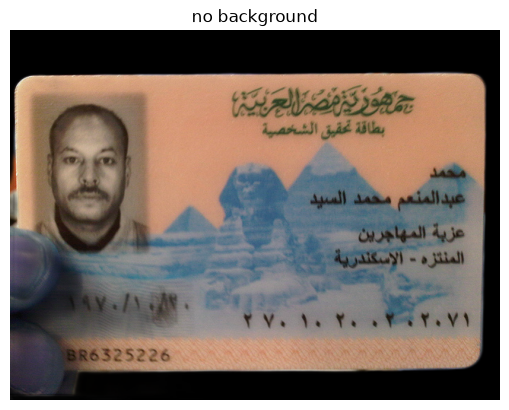

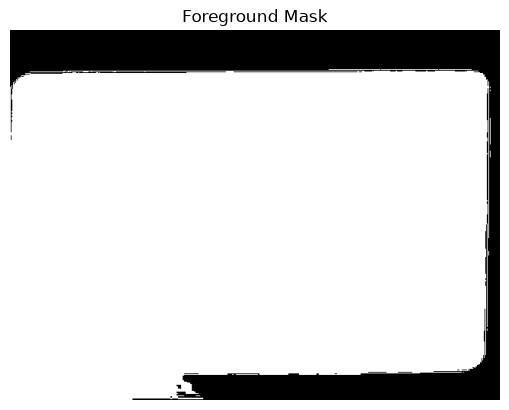

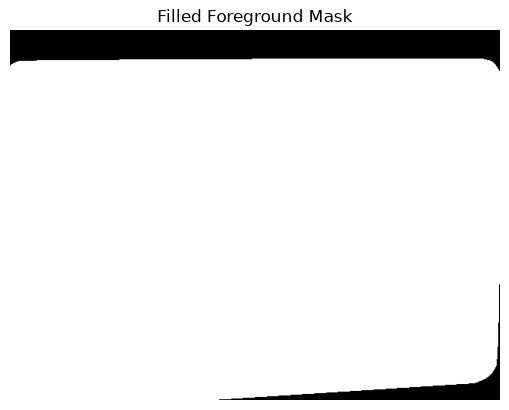

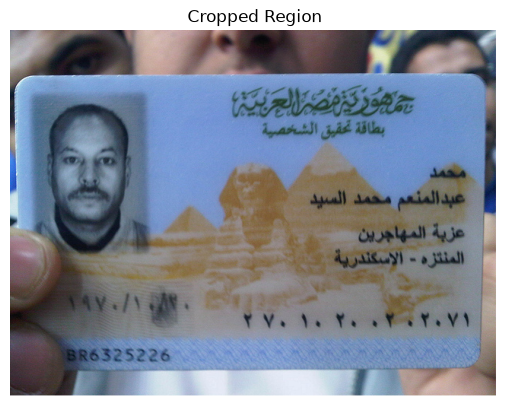

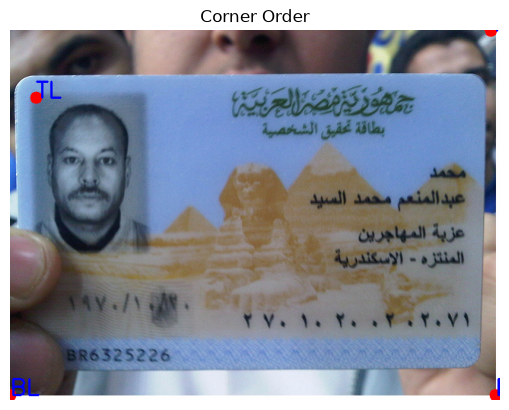

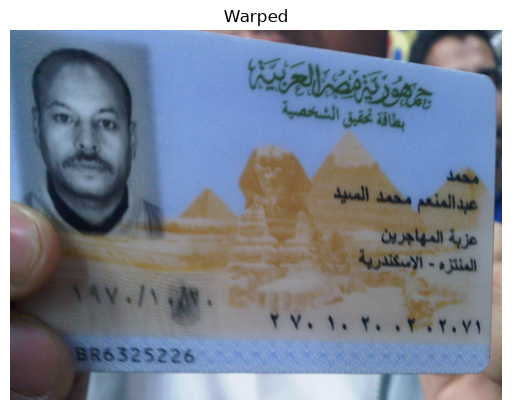

جَمهُرَ مص العَريَة  (conf: 0.47)
بطاقة تحقيق الشخصية  (conf: 0.91)
محمد  (conf: 1.00)
السيد  (conf: 1.00)
محمد  (conf: 1.00)
عبد المنعم  (conf: 0.92)
المهاجرين  (conf: 0.95)
عزية  (conf: 0.84)
الاسكندرية  (conf: 0.95)
المنتزه ١  (conf: 0.86)
٩٧٠١١٠٨٢  (conf: 0.87)
٢٧٠١٠٢٠٠٢٠٢٠٧١  (conf: 0.96)
R6325226  (conf: 1.00)


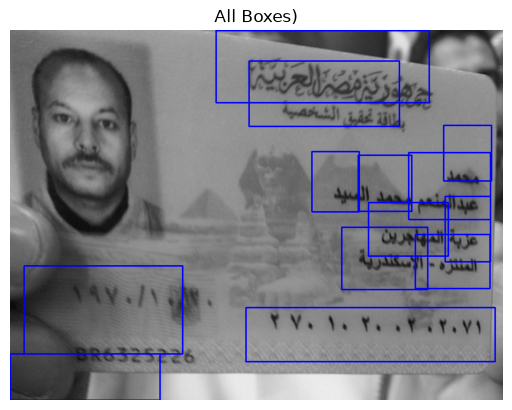

Detected orientation: 0.0


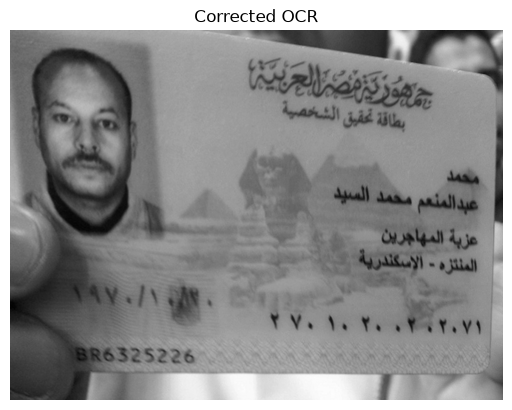

جَمهُرَ مص العَريَة  (conf: 0.47)
بطاقة تحقيق الشخصية  (conf: 0.91)
محمد  (conf: 1.00)
السيد  (conf: 1.00)
محمد  (conf: 1.00)
عبد المنعم  (conf: 0.92)
المهاجرين  (conf: 0.95)
عزية  (conf: 0.84)
الاسكندرية  (conf: 0.95)
المنتزه ١  (conf: 0.86)
٩٧٠١١٠٨٢  (conf: 0.87)
٢٧٠١٠٢٠٠٢٠٢٠٧١  (conf: 0.96)
R6325226  (conf: 1.00)


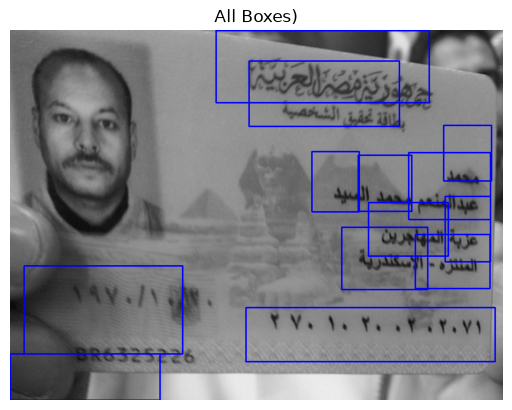

ID:   27010200202071
NAME: محمد عبد المنعم محمد السيد


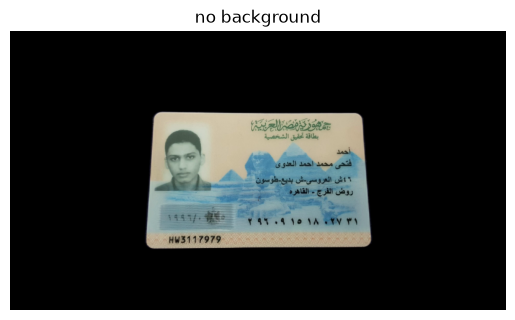

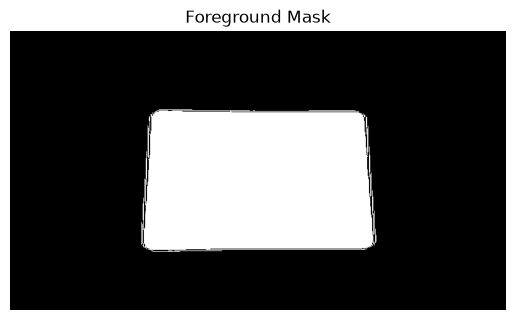

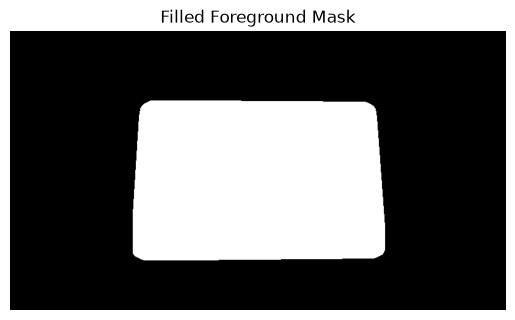

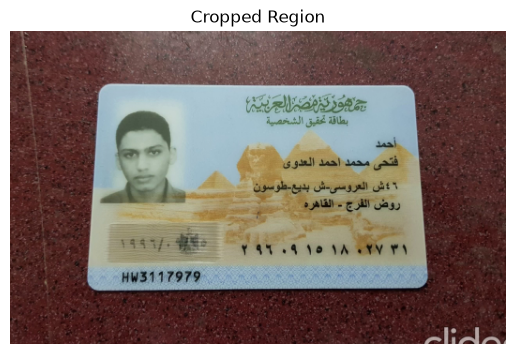

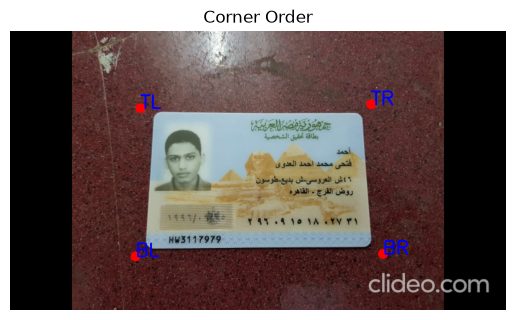

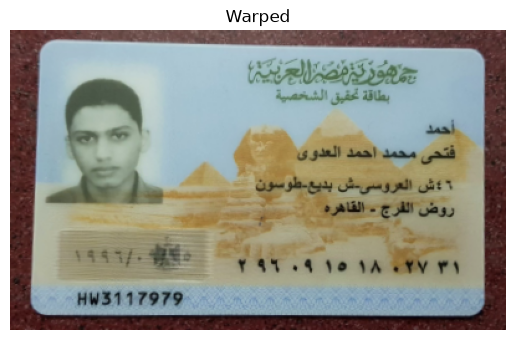

حهوَي مصَ العريَُ  (conf: 0.38)
بطاقة تحقيق الشخصية  (conf: 0.96)
أحمد  (conf: 1.00)
محمد احمد العدوى  (conf: 0.93)
فتحى  (conf: 0.92)
٦ ٤ ش العروسي ش بديع  طوسون  (conf: 0.89)
روض الفرج  القاهره  (conf: 0.93)
١٩٩٦/٠  (conf: 0.94)
UE.  (conf: 0.40)
٢٩٦٠٩١٥١٨٠٢٧٣١  (conf: 0.96)
HW3117979  (conf: 1.00)


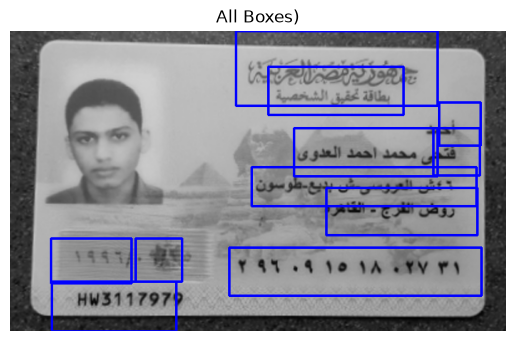

Detected orientation: 0.0


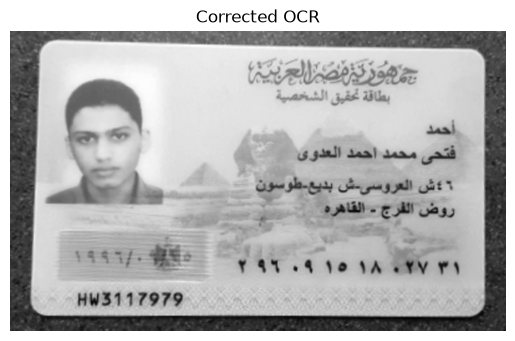

حهوَي مصَ العريَُ  (conf: 0.38)
بطاقة تحقيق الشخصية  (conf: 0.96)
أحمد  (conf: 1.00)
محمد احمد العدوى  (conf: 0.93)
فتحى  (conf: 0.92)
٦ ٤ ش العروسي ش بديع  طوسون  (conf: 0.89)
روض الفرج  القاهره  (conf: 0.93)
١٩٩٦/٠  (conf: 0.94)
UE.  (conf: 0.40)
٢٩٦٠٩١٥١٨٠٢٧٣١  (conf: 0.96)
HW3117979  (conf: 1.00)


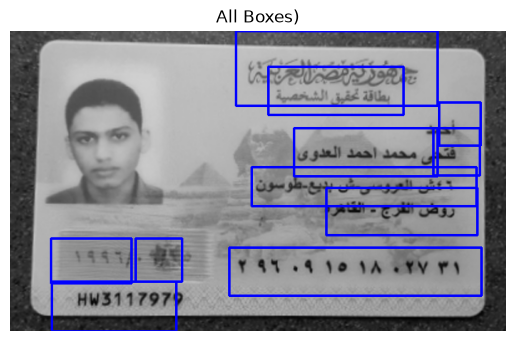

ID:   29609151802731
NAME: أحمد فتحى محمد احمد العدوى


In [195]:
def main(image_paths):
    results = []
    for path in image_paths:
        raw = cv2.imread(path)
        if raw is None:
            print(f"Could not read image: {path}")
            results.append({"path": path, "error": "could not read image"})
            continue
        warped = PerspectiveTransform(raw, path)
        if warped is None:
            print("Perspective transform failed")
            warped = raw
        prepped = makeImageBetter(warped)
        corrected = correctImageUsingTEXT(prepped)
        fullTXT, boxes = getText(corrected)
        groupedTXT = groupTextByLine(fullTXT, boxes, y_threshold=25)
        ID = extractIDFromText(fullTXT)
        Name = getName(fullTXT, groupedTXT)
        print(f"ID:   {ID}")
        print(f"NAME: {Name}")
        results.append({
            "path": path,
            "text": fullTXT,
            "boxes": boxes,
            "corrected_image": corrected
        })

     

    return results


if __name__ == "__main__":
    image_paths = [
        "imagesToTest/testEgID.png",
        "imagesToTest/testEgID3.png",
    ]
    results = main(image_paths)